In [181]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable


In [182]:
!pip install pandas --pre

Defaulting to user installation because normal site-packages is not writeable


In [183]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [184]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [185]:
!pip install scikit-learn 

Defaulting to user installation because normal site-packages is not writeable


In [186]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("All libraries imported successfully")

Pandas: 3.0.3
NumPy: 2.4.6
All libraries imported successfully


In [188]:
import os

data_path = "Data/set-a"

print("Folder exists:", os.path.exists(data_path))

files = os.listdir(data_path)

print("Number of files:", len(files))
print("First 5 files:", files[:5])

Folder exists: True
Number of files: 4000
First 5 files: ['132539.txt', '132540.txt', '132541.txt', '132543.txt', '132545.txt']


In [189]:
import pandas as pd

sample_file = "Data/set-a/132539.txt"

df = pd.read_csv(sample_file)

print(df.head())
print("\nShape:", df.shape)

    Time Parameter     Value
0  00:00  RecordID  132539.0
1  00:00       Age      54.0
2  00:00    Gender       0.0
3  00:00    Height      -1.0
4  00:00   ICUType       4.0

Shape: (273, 3)


In [190]:
print(df["Parameter"].unique())

<StringArray>
[  'RecordID',        'Age',     'Gender',     'Height',    'ICUType',
     'Weight',        'GCS',         'HR',  'NIDiasABP',      'NIMAP',
   'NISysABP',   'RespRate',       'Temp',      'Urine',        'HCT',
        'BUN', 'Creatinine',    'Glucose',       'HCO3',         'Mg',
  'Platelets',          'K',         'Na',        'WBC']
Length: 24, dtype: str


In [191]:
print("Number of unique parameters:", df["Parameter"].nunique())

Number of unique parameters: 24


In [192]:
df.head(20)

,Time,Parameter,Value
0,00:00,RecordID,132539.00
1,00:00,Age,54.00
2,00:00,Gender,0.00
3,00:00,Height,-1.00
4,00:00,ICUType,4.00
5,00:00,Weight,-1.00
6,00:07,GCS,15.00
7,00:07,HR,73.00
8,00:07,NIDiasABP,65.00
9,00:07,NIMAP,92.33


In [193]:
for item in os.listdir("Data"):
    print(item)

Outcomes-a.txt
set-a


In [194]:
import pandas as pd

outcomes = pd.read_csv("Data/Outcomes-a.txt")

print(outcomes.head())
print("\nShape:", outcomes.shape)
print("\nColumns:", outcomes.columns.tolist())

   RecordID  SAPS-I  SOFA  Length_of_stay  Survival  In-hospital_death
0    132539       6     1               5        -1                  0
1    132540      16     8               8        -1                  0
2    132541      21    11              19        -1                  0
3    132543       7     1               9       575                  0
4    132545      17     2               4       918                  0

Shape: (4000, 6)

Columns: ['RecordID', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death']


In [195]:
Shape: (4000, ...)

In [196]:
outcomes.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   RecordID           4000 non-null   int64
 1   SAPS-I             4000 non-null   int64
 2   SOFA               4000 non-null   int64
 3   Length_of_stay     4000 non-null   int64
 4   Survival           4000 non-null   int64
 5   In-hospital_death  4000 non-null   int64
dtypes: int64(6)
memory usage: 187.6 KB


In [197]:
outcomes["In-hospital_death"].value_counts()

In-hospital_death
0    3446
1     554
Name: count, dtype: int64

In [198]:
import pandas as pd
import os

sample_file = "Data/set-a/132539.txt"

df = pd.read_csv(sample_file)

patient_features = (
    df.groupby("Parameter")["Value"]
      .mean()
      .reset_index()
)

print(patient_features.head(20))

     Parameter          Value
0          Age      54.000000
1          BUN      10.500000
2   Creatinine       0.750000
3          GCS      14.923077
4       Gender       0.000000
5      Glucose     160.000000
6         HCO3      27.000000
7          HCT      32.500000
8           HR      70.810811
9       Height      -1.000000
10     ICUType       4.000000
11           K       4.200000
12          Mg       1.700000
13   NIDiasABP      50.147059
14       NIMAP      71.559118
15    NISysABP     114.382353
16          Na     136.500000
17   Platelets     203.000000
18    RecordID  132539.000000
19    RespRate      17.428571


In [199]:
import pandas as pd
import os

data_folder = "Data/set-a"

all_patients = []

for file in os.listdir(data_folder):

    if file.endswith(".txt"):

        path = os.path.join(data_folder, file)

        df = pd.read_csv(path)

        features = df.groupby("Parameter")["Value"].mean()

        patient_row = features.to_dict()

        patient_row["RecordID"] = int(file.replace(".txt", ""))

        all_patients.append(patient_row)

patient_df = pd.DataFrame(all_patients)

print(patient_df.shape)
patient_df.head()

(4000, 42)


,Age,BUN,Creatinine,GCS,Gender,Glucose,HCO3,HCT,HR,Height,...,pH,ALP,ALT,AST,Albumin,Bilirubin,Lactate,Cholesterol,TroponinI,TroponinT
0,54.0,10.500000,0.750000,14.923077,0.0,160.000000,27.000000,32.500000,70.810811,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,76.0,18.333333,1.100000,13.333333,1.0,125.500000,22.333333,28.655556,80.794118,175.3,...,7.395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,44.0,4.666667,0.333333,5.923077,0.0,134.333333,25.000000,28.460000,83.759259,-1.0,...,7.495,116.0,83.0,199.5,2.5,2.9,1.366667,NaN,NaN,NaN
3,68.0,17.666667,0.766667,14.944444,1.0,117.333333,27.666667,37.442857,70.983333,180.3,...,NaN,105.0,12.0,15.0,4.4,0.2,NaN,NaN,NaN,NaN
4,88.0,35.000000,1.000000,15.000000,0.0,102.500000,19.000000,29.550000,74.958333,-1.0,...,NaN,NaN,NaN,NaN,3.3,NaN,NaN,NaN,NaN,NaN


In [200]:
patient_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          4000 non-null   float64
 1   BUN          3936 non-null   float64
 2   Creatinine   3936 non-null   float64
 3   GCS          3936 non-null   float64
 4   Gender       4000 non-null   float64
 5   Glucose      3887 non-null   float64
 6   HCO3         3924 non-null   float64
 7   HCT          3936 non-null   float64
 8   HR           3937 non-null   float64
 9   Height       4000 non-null   float64
 10  ICUType      4000 non-null   float64
 11  K            3904 non-null   float64
 12  Mg           3897 non-null   float64
 13  NIDiasABP    3483 non-null   float64
 14  NIMAP        3481 non-null   float64
 15  NISysABP     3493 non-null   float64
 16  Na           3925 non-null   float64
 17  Platelets    3932 non-null   float64
 18  RecordID     4000 non-null   int64  
 19  RespRate     1101

In [201]:
patient_df.shape
patient_df.head()
patient_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          4000 non-null   float64
 1   BUN          3936 non-null   float64
 2   Creatinine   3936 non-null   float64
 3   GCS          3936 non-null   float64
 4   Gender       4000 non-null   float64
 5   Glucose      3887 non-null   float64
 6   HCO3         3924 non-null   float64
 7   HCT          3936 non-null   float64
 8   HR           3937 non-null   float64
 9   Height       4000 non-null   float64
 10  ICUType      4000 non-null   float64
 11  K            3904 non-null   float64
 12  Mg           3897 non-null   float64
 13  NIDiasABP    3483 non-null   float64
 14  NIMAP        3481 non-null   float64
 15  NISysABP     3493 non-null   float64
 16  Na           3925 non-null   float64
 17  Platelets    3932 non-null   float64
 18  RecordID     4000 non-null   int64  
 19  RespRate     1101

In [202]:
final_df = patient_df.merge(
    outcomes[["RecordID", "In-hospital_death"]],
    on="RecordID",
    how="inner"
)

print(final_df.shape)
final_df.head()

(4000, 43)


,Age,BUN,Creatinine,GCS,Gender,Glucose,HCO3,HCT,HR,Height,...,ALP,ALT,AST,Albumin,Bilirubin,Lactate,Cholesterol,TroponinI,TroponinT,In-hospital_death
0,54.0,10.500000,0.750000,14.923077,0.0,160.000000,27.000000,32.500000,70.810811,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,76.0,18.333333,1.100000,13.333333,1.0,125.500000,22.333333,28.655556,80.794118,175.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,44.0,4.666667,0.333333,5.923077,0.0,134.333333,25.000000,28.460000,83.759259,-1.0,...,116.0,83.0,199.5,2.5,2.9,1.366667,NaN,NaN,NaN,0
3,68.0,17.666667,0.766667,14.944444,1.0,117.333333,27.666667,37.442857,70.983333,180.3,...,105.0,12.0,15.0,4.4,0.2,NaN,NaN,NaN,NaN,0
4,88.0,35.000000,1.000000,15.000000,0.0,102.500000,19.000000,29.550000,74.958333,-1.0,...,NaN,NaN,NaN,3.3,NaN,NaN,NaN,NaN,NaN,0


In [203]:
print(final_df.isnull().sum().sort_values(ascending=False).head(20))

TroponinI      3795
Cholesterol    3695
TroponinT      3137
RespRate       2899
Albumin        2385
ALP            2310
Bilirubin      2282
ALT            2279
AST            2275
SaO2           2208
Lactate        1817
MechVent       1471
FiO2           1283
MAP            1208
SysABP         1201
DiasABP        1201
PaCO2           977
PaO2            977
pH              960
NIMAP           519
dtype: int64


In [204]:
final_df = final_df.fillna(final_df.median(numeric_only=True))

In [205]:
X = final_df.drop("In-hospital_death", axis=1)
y = final_df["In-hospital_death"]

print(X.shape)
print(y.shape)

(4000, 42)
(4000,)


In [206]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8725


In [207]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8725
Precision: 0.7142857142857143
Recall   : 0.13513513513513514
F1 Score : 0.22727272727272727

Confusion Matrix:
[[683   6]
 [ 96  15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       689
           1       0.71      0.14      0.23       111

    accuracy                           0.87       800
   macro avg       0.80      0.56      0.58       800
weighted avg       0.85      0.87      0.83       800



In [208]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [209]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy : 0.86125
Precision: 0.5
Recall   : 0.32432432432432434
F1 Score : 0.39344262295081966

Confusion Matrix:
[[653  36]
 [ 75  36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       689
           1       0.50      0.32      0.39       111

    accuracy                           0.86       800
   macro avg       0.70      0.64      0.66       800
weighted avg       0.84      0.86      0.85       800



In [210]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


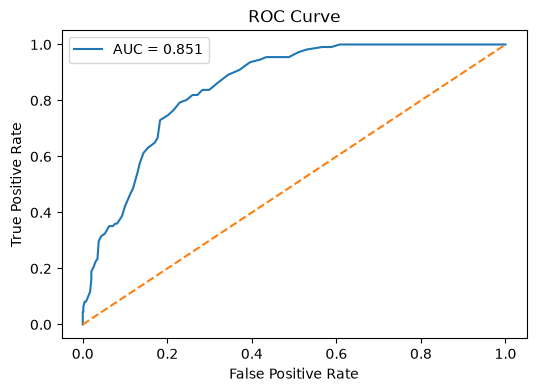

AUC Score: 0.8512925116698702


In [211]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

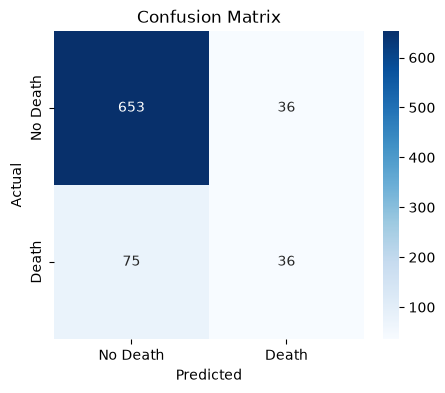

In [212]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Death','Death'],
            yticklabels=['No Death','Death'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

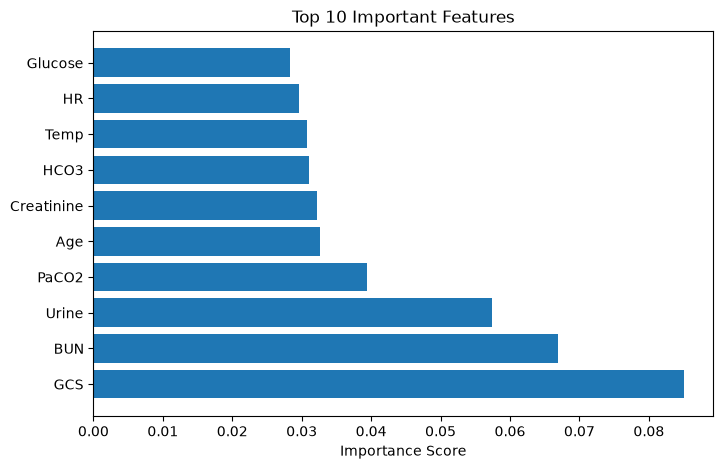

In [213]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

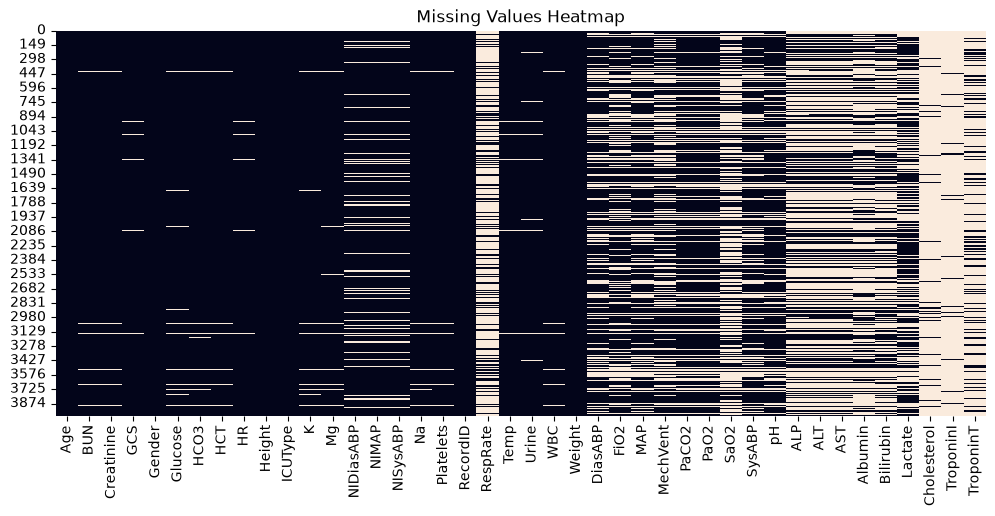

In [214]:
import seaborn as sns

plt.figure(figsize=(12,5))
sns.heatmap(
    patient_df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.show()

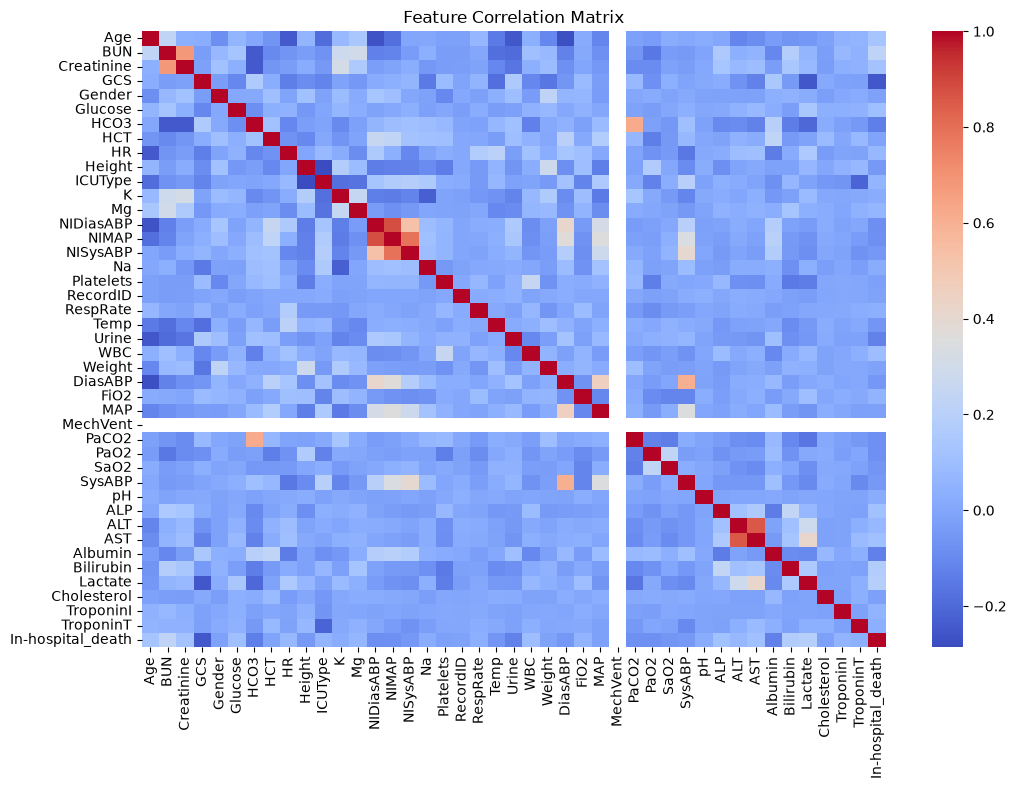

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    final_df.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")
plt.show()

In [216]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, y_pred_xgb)
)

XGBoost Accuracy: 0.8675


In [217]:
risk_prob = model.predict_proba(X_test)[:,1]


In [218]:
risk = risk_prob[0]

print("Risk Probability:", risk)

if risk > 0.7:
    print("⚠️ High Risk")
elif risk > 0.3:
    print("⚠️ Medium Risk")
else:
    print("✅ Low Risk")

Risk Probability: 0.02
✅ Low Risk


In [219]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [220]:
import shap
import matplotlib.pyplot as plt

In [221]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [222]:
import shap
import matplotlib.pyplot as plt
import os

os.makedirs("static", exist_ok=True)

explainer = shap.TreeExplainer(xgb_small)

shap_values = explainer.shap_values(X_test_small)

plt.figure()

shap.summary_plot(
    shap_values,
    X_test_small,
    show=False
)

plt.savefig(
    "static/shap_summary.png",
    bbox_inches="tight"
)

plt.close()

print("SHAP image saved successfully")

SHAP image saved successfully


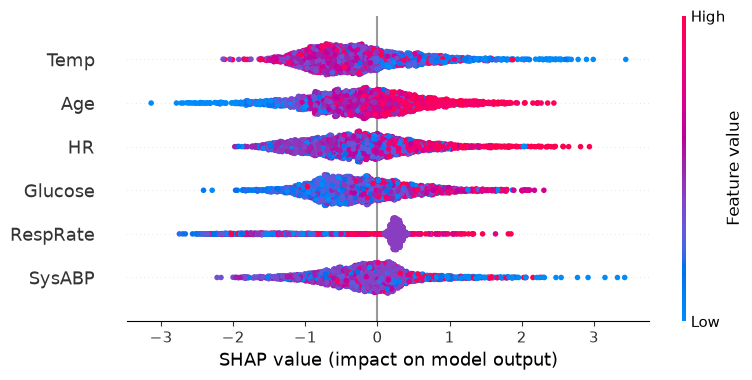

In [224]:
shap.summary_plot(
    shap_values,
    X_test_small,
    feature_names=X_test_small.columns
)

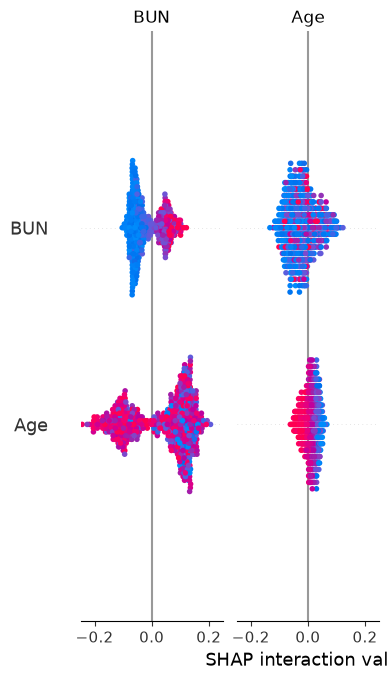

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    plot_type="bar"
)

<Figure size 1000x600 with 0 Axes>

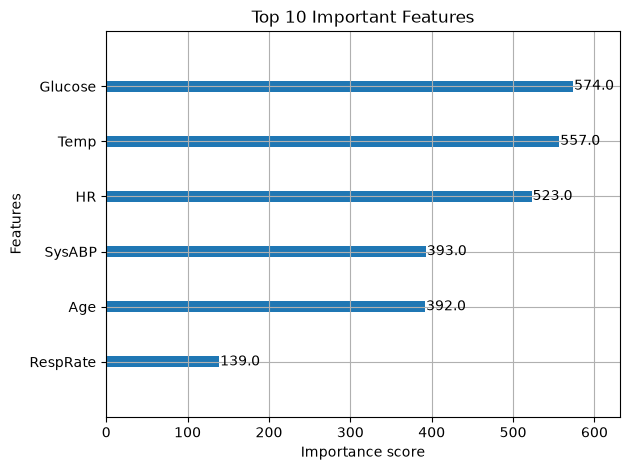

✅ Feature Importance displayed and saved successfully


In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
import os

os.makedirs("static", exist_ok=True)

plt.figure(figsize=(10,6))
plot_importance(xgb_small, max_num_features=10)
plt.title("Top 10 Important Features")
plt.tight_layout()

plt.savefig("static/feature_importance.png")

plt.show()

print("✅ Feature Importance displayed and saved successfully")

In [ ]:
print(X_test.shape)
print(y_test.shape)

(800, 42)
(800,)


In [ ]:
import joblib

joblib.dump(xgb, "model.pkl")

print("Model saved successfully")

Model saved successfully


In [ ]:
print(type(xgb))

<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
import joblib
model = joblib.load("model.pkl")

In [ ]:
print(X_train.columns.tolist())

['Age', 'BUN', 'Creatinine', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'Platelets', 'RecordID', 'RespRate', 'Temp', 'Urine', 'WBC', 'Weight', 'DiasABP', 'FiO2', 'MAP', 'MechVent', 'PaCO2', 'PaO2', 'SaO2', 'SysABP', 'pH', 'ALP', 'ALT', 'AST', 'Albumin', 'Bilirubin', 'Lactate', 'Cholesterol', 'TroponinI', 'TroponinT']


In [ ]:
print(len(X_train.columns))

42


In [ ]:
selected_features = [
    'Age',
    'Glucose',
    'HR',
    'Temp',
    'SysABP',
    'RespRate'
]

X_test_small = X_train[selected_features]
print(X_test_small.head())

       Age     Glucose         HR       Temp      SysABP   RespRate
2067  56.0  114.500000  91.767857  36.745455  118.214286  14.875000
889   52.0  115.200000  90.955224  35.849231  101.204545  19.050000
618   39.0  111.500000  84.145833  36.625000  121.212766  19.050000
400   81.0  181.333333  69.217391  36.766667   99.782609  17.586957
1546  50.0   93.375000  80.652174  36.418182  117.047619  14.888889


In [ ]:
from xgboost import XGBClassifier

xgb_small = XGBClassifier()

xgb_small.fit(X_small, y_train)

import joblib
joblib.dump(xgb_small, "model.pkl")

print("New 6-feature model saved successfully")

New 6-feature model saved successfully


In [ ]:
print(X_test_small.shape)
print(X_test_small.columns.tolist())

(3200, 6)
['Age', 'Glucose', 'HR', 'Temp', 'SysABP', 'RespRate']


In [ ]:
y_prob = xgb_small.predict_proba(X_test_small)[:,1]

print(y_prob[:5])

[2.7700621e-04 8.2422769e-01 1.3452824e-02 2.3980314e-02 8.0772884e-02]


In [225]:
print(y_train.value_counts())

In-hospital_death
0    2757
1     443
Name: count, dtype: int64


In [226]:
print(X_train[selected_features].describe())

               Age      Glucose           HR         Temp       SysABP  \
count  3200.000000  3200.000000  3200.000000  3200.000000  3200.000000   
mean     64.426875   137.163149    87.106565    36.958713   118.026879   
std      17.491881    39.126206    14.443484     0.744374    16.703845   
min      15.000000    52.500000    42.784314    21.644615     0.000000   
25%      53.000000   112.729167    77.157537    36.615385   110.884615   
50%      67.000000   129.333333    86.325581    36.975205   117.047619   
75%      78.000000   151.812500    96.436298    37.361703   123.484375   
max      90.000000   446.333333   137.842105    39.748980   181.725000   

          RespRate  
count  3200.000000  
mean     19.200217  
std       2.017821  
min      10.877193  
25%      19.050000  
50%      19.050000  
75%      19.050000  
max      37.387755  


In [227]:
test = pd.DataFrame([{
    "Age": 80,
    "Glucose": 400,
    "HR": 130,
    "Temp": 39,
    "SysABP": 70,
    "RespRate": 35
}])

print(xgb_small.predict(test))
print(xgb_small.predict_proba(test))

[1]
[[0.3431818 0.6568182]]
